In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

# DMSO Data Prep

In [62]:
"""
Since this is general it is only reading the "summarized" file
"""
tst_DMSO = pd.read_csv('data/test/G0_DMSO_summary.csv')
tr_DMSO = pd.read_csv('data/train/G0_DMSO_summary.csv')



# Group 1 Data Prep

## Getting General Group 1 data

In [34]:
"""
Since this is general it is only reading the "summarized" file
"""
tst_g1_T0374 = pd.read_csv('data/test/G1_T0374_summary.csv')
tst_g1_T0374L = pd.read_csv('data/test/G1_T0374L_summary.csv')
tst_g1_T1912 = pd.read_csv('data/test/G1_T1912_summary.csv')
tst_g1_T1995 = pd.read_csv('data/test/G1_T1995_summary.csv')
tst_g1_T6020 = pd.read_csv('data/test/G1_T6020_summary.csv')
tst_g1_T7394 = pd.read_csv('data/test/G1_T7394_summary.csv')

tr_g1_T0374 = pd.read_csv('data/train/G1_T0374_summary.csv')
tr_g1_T0374L = pd.read_csv('data/train/G1_T0374L_summary.csv')
tr_g1_T1912 = pd.read_csv('data/train/G1_T1912_summary.csv')
tr_g1_T1995 = pd.read_csv('data/train/G1_T1995_summary.csv')
tr_g1_T6020 = pd.read_csv('data/train/G1_T6020_summary.csv')
tr_g1_T7394 = pd.read_csv('data/train/G1_T7394_summary.csv')



g1_T0374 = pd.concat([tst_g1_T0374, tr_g1_T0374])
medicine = "T0374"
g1_T0374['Medicine']=medicine

g1_T0374L = pd.concat([tst_g1_T0374L, tr_g1_T0374L])
medicine = "T0374L"
g1_T0374L['Medicine'] = medicine

g1_T1912 = pd.concat([tst_g1_T1912, tr_g1_T1912])
medicine = "T1912"
g1_T1912['Medicine'] = medicine

g1_T1995 = pd.concat([tst_g1_T1995, tr_g1_T1995])
medicine = "T1995"
g1_T1995['Medicine'] = medicine

g1_T6020 = pd.concat([tst_g1_T6020, tr_g1_T6020])
medicine = "T6020"
g1_T6020['Medicine'] = medicine

g1_T7394 = pd.concat([tst_g1_T7394, tr_g1_T7394])
medicine = "T7394"
g1_T7394['Medicine'] = medicine

In [35]:
"""
    Detecting and getting rid of "NaN" values
"""
g1_T0374 = g1_T0374.dropna()
g1_T0374L = g1_T0374L.dropna()
g1_T1912 = g1_T1912.dropna()
g1_T1995 = g1_T1995.dropna()
g1_T6020 = g1_T6020.dropna()
g1_T7394 = g1_T7394.dropna()

In [36]:
"""
    Merging tables to get master table for group 1
"""
g1_master_table = pd.concat([g1_T0374, g1_T0374L, g1_T1912, g1_T1995, g1_T6020, g1_T7394], ignore_index=True)

g1_master_table


,group,image,mean_dist_nucleus,mean_dist_mito,n_pbody,Medicine
0,G1,W0017F0001T0006Z000C1N11.png,3.049095,3.925566,29,T0374
1,G1,W0017F0001T0006Z000C1N20.png,11.221732,28.517091,25,T0374
2,G1,W0017F0001T0006Z000C1N21.png,15.030094,24.074763,20,T0374
3,G1,W0017F0001T0006Z000C1N23.png,0.964987,33.527823,5,T0374
4,G1,W0017F0001T0006Z000C1N24.png,7.269820,26.026619,12,T0374
...,...,...,...,...,...,...
2249,G1,W0056F0003T0006Z000C1N83.png,19.810247,38.447979,5,T7394
2250,G1,W0056F0003T0006Z000C1N88.png,3.320626,12.015882,9,T7394
2251,G1,W0056F0003T0006Z000C1N89.png,0.256963,0.256963,908,T7394
2252,G1,W0056F0003T0006Z000C1N9.png,9.381688,20.832514,13,T7394


In [38]:
"""
    Adding standard deviation to master table
"""

g1_master_table['std_nucleus'] = g1_master_table.groupby('Medicine')['mean_dist_nucleus'].transform('std')
g1_master_table['std_mito'] = g1_master_table.groupby('Medicine')['mean_dist_mito'].transform('std')

g1_master_table

,group,image,mean_dist_nucleus,mean_dist_mito,n_pbody,Medicine,std_nucleus,std_mito
0,G1,W0017F0001T0006Z000C1N11.png,3.049095,3.925566,29,T0374,0.0,0.0
1,G1,W0017F0001T0006Z000C1N20.png,11.221732,28.517091,25,T0374,0.0,0.0
2,G1,W0017F0001T0006Z000C1N21.png,15.030094,24.074763,20,T0374,0.0,0.0
3,G1,W0017F0001T0006Z000C1N23.png,0.964987,33.527823,5,T0374,0.0,0.0
4,G1,W0017F0001T0006Z000C1N24.png,7.269820,26.026619,12,T0374,0.0,0.0
...,...,...,...,...,...,...,...,...
2249,G1,W0056F0003T0006Z000C1N83.png,19.810247,38.447979,5,T7394,0.0,0.0
2250,G1,W0056F0003T0006Z000C1N88.png,3.320626,12.015882,9,T7394,0.0,0.0
2251,G1,W0056F0003T0006Z000C1N89.png,0.256963,0.256963,908,T7394,0.0,0.0
2252,G1,W0056F0003T0006Z000C1N9.png,9.381688,20.832514,13,T7394,0.0,0.0


# Group 2 Data Prep

## Getting General Group 2 data

In [6]:
"""
Since this is general it is only reading the "summarized" file
"""

tst_g2_T0860 = pd.read_csv('data/test/G2_T0860_summary.csv')
tst_g2_T1448 = pd.read_csv('data/test/G2_T1448_summary.csv')
tst_g2_T1656 = pd.read_csv('data/test/G2_T1656_summary.csv')
tst_g2_T2508 = pd.read_csv('data/test/G2_T2508_summary.csv')
tst_g2_T2509 = pd.read_csv('data/test/G2_T2509_summary.csv')
tst_g2_T3380 = pd.read_csv('data/test/G2_T3380_summary.csv')

tr_g2_T0860 = pd.read_csv('data/train/G2_T0860_summary.csv')
tr_g2_T1448 = pd.read_csv('data/train/G2_T1448_summary.csv')
tr_g2_T1656 = pd.read_csv('data/train/G2_T1656_summary.csv')
tr_g2_T2508 = pd.read_csv('data/train/G2_T2508_summary.csv')
tr_g2_T2509 = pd.read_csv('data/train/G2_T2509_summary.csv')
tr_g2_T3380 = pd.read_csv('data/train/G2_T3380_summary.csv')

g2_T0860 = pd.concat([tst_g2_T0860, tr_g2_T0860])
medicine = "T0860"
g2_T0860['Medicine'] = medicine

g2_T1448 = pd.concat([tst_g2_T1448, tr_g2_T1448])
medicine = "T1448"
g2_T1448['Medicine'] = medicine

g2_T1656 = pd.concat([tst_g2_T1656, tr_g2_T1656])
medicine = "T1656"
g2_T1656['Medicine'] = medicine

g2_T2508 = pd.concat([tst_g2_T2508, tr_g2_T2508])
medicine = "T2508"
g2_T2508['Medicine'] = medicine

g2_T2509 = pd.concat([tst_g2_T2509, tr_g2_T2509])
medicine = "T2509"
g2_T2509['Medicine'] = medicine

g2_T3380 = pd.concat([tst_g2_T3380, tr_g2_T3380])
medicine = "T3380"
g2_T3380['Medicine'] = medicine


In [7]:
"""
    Detecting and getting rid of "NaN" values
"""

g2_T0860 = g2_T0860.dropna()
g2_T1448 = g2_T1448.dropna()
g2_T1656 = g2_T1656.dropna()
g2_T2508 = g2_T2508.dropna()
g2_T2509 = g2_T2509.dropna()
g2_T3380 = g2_T3380.dropna()

In [8]:
"""
    Merging tables to get master table for group 2
"""
g2_master_table = pd.concat([g2_T0860, g2_T1448, g2_T1656, g2_T2508, g2_T2509, g2_T3380], ignore_index=True)

In [9]:
"""
    Adding standard deviation to master table
"""

g2_master_table['std_nucleus'] = g2_master_table.groupby('Medicine')['mean_dist_nucleus'].transform('std')
g2_master_table['std_mito'] = g2_master_table.groupby('Medicine')['mean_dist_mito'].transform('std')

g2_master_table

,group,image,mean_dist_nucleus,mean_dist_mito,n_pbody,Medicine,std_nucleus,std_mito
0,G2,W0027F0001T0006Z000C1N22.png,6.505202,20.956883,55,T0860,5.163534,15.229858
1,G2,W0027F0001T0006Z000C1N24.png,3.360335,3.372033,51,T0860,5.163534,15.229858
2,G2,W0027F0001T0006Z000C1N29.png,11.368487,39.698638,40,T0860,5.163534,15.229858
3,G2,W0027F0001T0006Z000C1N3.png,1.776947,1.987294,66,T0860,5.163534,15.229858
4,G2,W0027F0001T0006Z000C1N35.png,3.498627,11.141620,31,T0860,5.163534,15.229858
...,...,...,...,...,...,...,...,...
2752,G2,W0076F0003T0006Z000C1N3.png,1.348924,1.348924,98,T3380,4.138759,12.539107
2753,G2,W0076F0003T0006Z000C1N4.png,2.428507,2.432179,64,T3380,4.138759,12.539107
2754,G2,W0076F0003T0006Z000C1N5.png,5.518455,13.224504,36,T3380,4.138759,12.539107
2755,G2,W0076F0003T0006Z000C1N6.png,2.624373,3.149188,64,T3380,4.138759,12.539107


# Group 3 Data Prep

## Getting General Group 3 data

In [10]:
"""
Since this is general it is only reading the "summarized" file
"""

tst_g3_T0801 = pd.read_csv('data/test/G3_T0801_summary.csv')
tst_g3_T1829 = pd.read_csv('data/test/G3_T1829_summary.csv')
tst_g3_T2485 = pd.read_csv('data/test/G3_T2485_summary.csv')
tst_g3_T2677 = pd.read_csv('data/test/G3_T2677_summary.csv')
tst_g3_T6156 = pd.read_csv('data/test/G3_T6156_summary.csv')
tst_g3_T7503 = pd.read_csv('data/test/G3_T7503_summary.csv')

tr_g3_T0801 = pd.read_csv('data/train/G3_T0801_summary.csv')
tr_g3_T1829 = pd.read_csv('data/train/G3_T1829_summary.csv')
tr_g3_T2485 = pd.read_csv('data/train/G3_T2485_summary.csv')
tr_g3_T2677 = pd.read_csv('data/train/G3_T2677_summary.csv')
tr_g3_T6156 = pd.read_csv('data/train/G3_T6156_summary.csv')
tr_g3_T7503 = pd.read_csv('data/train/G3_T7503_summary.csv')

g3_T0801 = pd.concat([tst_g3_T0801, tr_g3_T0801])
medicine = 'T0801'
g3_T0801['Medicine'] = medicine

g3_T1829 = pd.concat([tst_g3_T1829, tr_g3_T1829])
medicine = "T1829"
g3_T1829["Medicine"] = medicine

g3_T2485 = pd.concat([tst_g3_T2485, tr_g3_T2485])
medicine = "T2485"
g3_T2485['Medicine'] = medicine

g3_T2677 = pd.concat([tst_g3_T2677, tr_g3_T2677])
medicine= "T2677"
g3_T2677["Medicine"] = medicine

g3_T6156 = pd.concat([tst_g3_T6156, tr_g3_T6156])
medicine = "T6156"
g3_T6156["Medicine"] = medicine

g3_T7503 = pd.concat([tst_g3_T7503, tr_g3_T7503])
medicine = "T7503"
g3_T7503["Medicine"] = medicine

In [11]:
"""
    Detecting and getting rid of "NaN" values
"""

g3_T0801 = g3_T0801.dropna()
g3_T1829 = g3_T1829.dropna()
g3_T2485 = g3_T2485.dropna()
g3_T2677 = g3_T2677.dropna()
g3_T6156 = g3_T6156.dropna()
g3_T7503 = g3_T7503.dropna()

In [12]:
"""
    Merging tables to get master table for group 3
"""

g3_master_table = pd.concat([g3_T0801, g3_T1829, g3_T2485, g3_T2677, g3_T6156, g3_T7503], ignore_index=True)

In [13]:
"""
    Adding standard deviation to master table
"""

g3_master_table['std_nucleus'] = g3_master_table.groupby('Medicine')['mean_dist_nucleus'].transform('std')
g3_master_table['std_mito'] = g3_master_table.groupby('Medicine')['mean_dist_mito'].transform('std')

g3_master_table

,group,image,mean_dist_nucleus,mean_dist_mito,n_pbody,Medicine,std_nucleus,std_mito
0,G3,W0022F0001T0006Z000C1N11.png,26.184128,66.368759,25,T0801,14.410893,27.087544
1,G3,W0022F0001T0006Z000C1N12.png,34.616948,34.616948,4,T0801,14.410893,27.087544
2,G3,W0022F0001T0006Z000C1N14.png,36.817832,94.831146,24,T0801,14.410893,27.087544
3,G3,W0022F0001T0006Z000C1N27.png,0.535092,0.535092,55,T0801,14.410893,27.087544
4,G3,W0022F0001T0006Z000C1N3.png,12.015711,22.343986,17,T0801,14.410893,27.087544
...,...,...,...,...,...,...,...,...
2152,G3,W0065F0003T0006Z000C1N4.png,41.935362,61.246142,8,T7503,13.595592,26.454563
2153,G3,W0065F0003T0006Z000C1N40.png,16.943905,21.268714,4,T7503,13.595592,26.454563
2154,G3,W0065F0003T0006Z000C1N42.png,16.834135,20.073577,9,T7503,13.595592,26.454563
2155,G3,W0065F0003T0006Z000C1N43.png,15.570110,47.667065,10,T7503,13.595592,26.454563


# Group 4 Data Prep

## Getting General Group 4 data

In [14]:
"""
Since this is general it is only reading the "summarized" file
"""

tst_g4_T2S0007 = pd.read_csv('data/test/G4_T2S0007_summary.csv')
tst_g4_T1929 = pd.read_csv('data/test/G4_T1929_summary.csv')
tst_g4_T1936 = pd.read_csv('data/test/G4_T1936_summary.csv')
tst_g4_T3211 = pd.read_csv('data/test/G4_T3211_summary.csv')
tst_g4_T3269 = pd.read_csv('data/test/G4_T3269_summary.csv')
tst_g4_T3603 = pd.read_csv('data/test/G4_T3603_summary.csv')
tst_g4_T3616 = pd.read_csv('data/test/G4_T3616_summary.csv')
tst_g4_T4883 = pd.read_csv('data/test/G4_T4883_summary.csv')
tst_g4_T5171 = pd.read_csv('data/test/G4_T5171_summary.csv')
tst_g4_T5177 = pd.read_csv('data/test/G4_T5177_summary.csv')
tst_g4_T6321 = pd.read_csv('data/test/G4_T6321_summary.csv')
tst_g4_T7486 = pd.read_csv('data/test/G4_T7486_summary.csv')
tst_g4_T7861 = pd.read_csv('data/test/G4_T7861_summary.csv')
tst_g4_T8482 = pd.read_csv('data/test/G4_T8482_summary.csv')

tr_g4_T2S0007 = pd.read_csv('data/train/G4_T2S0007_summary.csv')
tr_g4_T1929 = pd.read_csv('data/train/G4_T1929_summary.csv')
tr_g4_T1936 = pd.read_csv('data/train/G4_T1936_summary.csv')
tr_g4_T3211 = pd.read_csv('data/train/G4_T3211_summary.csv')
tr_g4_T3269 = pd.read_csv('data/train/G4_T3269_summary.csv')
tr_g4_T3603 = pd.read_csv('data/train/G4_T3603_summary.csv')
tr_g4_T3616 = pd.read_csv('data/train/G4_T3616_summary.csv')
tr_g4_T4883 = pd.read_csv('data/train/G4_T4883_summary.csv')
tr_g4_T5171 = pd.read_csv('data/train/G4_T5171_summary.csv')
tr_g4_T5177 = pd.read_csv('data/train/G4_T5177_summary.csv')
tr_g4_T6321 = pd.read_csv('data/train/G4_T6321_summary.csv')
tr_g4_T7486 = pd.read_csv('data/train/G4_T7486_summary.csv')
tr_g4_T7861 = pd.read_csv('data/train/G4_T7861_summary.csv')
tr_g4_T8482 = pd.read_csv('data/train/G4_T8482_summary.csv')

g4_T2S0007 = pd.concat([tst_g4_T2S0007, tr_g4_T2S0007])
medicine = "T2S0007"
g4_T2S0007['Medicine'] = medicine

g4_T1929 = pd.concat([tst_g4_T1929, tr_g4_T1929])
medicine ="T1929"
g4_T1929['Medicine'] = medicine

g4_T1936 = pd.concat([tst_g4_T1936, tr_g4_T1936])
medicine = "T1936"
g4_T1936['Medicine'] = medicine

g4_T3211 = pd.concat([tst_g4_T3211, tr_g4_T3211])
medicine = "T3211"
g4_T3211['Medicine'] = medicine

g4_T3269 = pd.concat([tst_g4_T3269, tr_g4_T3269])
medicine = "T3269"
g4_T3269['Medicine'] = medicine

g4_T3603 = pd.concat([tst_g4_T3603, tr_g4_T3603])
medicine = "T3603"
g4_T3603['Medicine'] = medicine

g4_T3616 = pd.concat([tst_g4_T3616, tr_g4_T3616])
medicine = "T3616"
g4_T3616['Medicine'] = medicine

g4_T4883 = pd.concat([tst_g4_T4883, tr_g4_T4883])
medicine = "T4883"
g4_T4883['Medicine'] = medicine

g4_T5171 = pd.concat([tst_g4_T5171, tr_g4_T5171])
medicine = "T5171"
g4_T5171['Medicine'] = medicine

g4_T5177 = pd.concat([tst_g4_T5177, tr_g4_T5177])
medicine = "T5177"
g4_T5177['Medicine'] = medicine

g4_T6321 = pd.concat([tst_g4_T6321, tr_g4_T6321])
medicine = "T6321"
g4_T6321['Medicine'] = medicine

g4_T7486 = pd.concat([tst_g4_T7486, tr_g4_T7486])
medicine = "T7486"
g4_T7486['Medicine'] = medicine

g4_T7861 = pd.concat([tst_g4_T7861, tr_g4_T7861])
medicine = "T7861"
g4_T7861['Medicine'] = medicine

g4_T8482 = pd.concat([tst_g4_T8482, tr_g4_T8482])
medicine = "T8482"
g4_T8482['Medicine'] = medicine

In [15]:
"""
    Detecting and getting rid of "NaN" values
"""

g4_T2S0007 = g4_T2S0007.dropna()
g4_T1929 = g4_T1929.dropna()
g4_T1936 = g4_T1936.dropna()
g4_T3211 = g4_T3211.dropna()
g4_T3269 = g4_T3269.dropna()
g4_T3603 = g4_T3603.dropna()
g4_T3616 = g4_T3616.dropna()
g4_T4883 = g4_T4883.dropna()
g4_T5171 = g4_T5171.dropna()
g4_T5177 = g4_T5177.dropna()
g4_T6321 = g4_T6321.dropna()
g4_T7486 = g4_T7486.dropna()
g4_T7861 = g4_T7861.dropna()
g4_T8482 = g4_T8482.dropna()

In [16]:
"""
    Merging tables to get master table for group 4
"""

g4_master_table = pd.concat([g4_T2S0007, g4_T1929, g4_T1936, g4_T3211, g4_T3269, g4_T3603, g4_T3616, g4_T4883, g4_T5171, g4_T5177, g4_T6321, g4_T7486, g4_T7861, g4_T8482], ignore_index=True)

In [17]:
"""
    Adding standard deviation to master table
"""

g4_master_table['std_nucleus'] = g4_master_table.groupby('Medicine')['mean_dist_nucleus'].transform('std')
g4_master_table['std_mito'] = g4_master_table.groupby('Medicine')['mean_dist_mito'].transform('std')

g4_master_table

,group,image,mean_dist_nucleus,mean_dist_mito,n_pbody,Medicine,std_nucleus,std_mito
0,G4,W0023F0001T0006Z000C1N1.png,0.843038,0.843038,118,T2S0007,11.345473,15.285006
1,G4,W0023F0001T0006Z000C1N12.png,4.905607,4.905607,572,T2S0007,11.345473,15.285006
2,G4,W0023F0001T0006Z000C1N13.png,10.434067,11.225819,30,T2S0007,11.345473,15.285006
3,G4,W0023F0001T0006Z000C1N14.png,6.891085,7.021919,25,T2S0007,11.345473,15.285006
4,G4,W0023F0001T0006Z000C1N18.png,14.697649,15.547281,20,T2S0007,11.345473,15.285006
...,...,...,...,...,...,...,...,...
22343,G4,W0074F0003T0006Z000C1N3.png,29.784581,30.271097,20,T8482,13.764052,17.967122
22344,G4,W0074F0003T0006Z000C1N30.png,0.371111,0.371111,10,T8482,13.764052,17.967122
22345,G4,W0074F0003T0006Z000C1N31.png,0.176846,0.176846,412,T8482,13.764052,17.967122
22346,G4,W0074F0003T0006Z000C1N4.png,10.141700,10.141700,27,T8482,13.764052,17.967122


# Group 5 Data Prep

## Getting General Group 5 data

In [18]:
"""
Since this is general it is only reading the "summarized" file
"""

tst_g5_T1791 = pd.read_csv('data/test/G5_T1791_summary.csv')
tst_g5_T1791L = pd.read_csv('data/test/G5_T1791L_summary.csv')
tst_g5_T2372 = pd.read_csv('data/test/G5_T2372_summary.csv')
tst_g5_T6165 = pd.read_csv('data/test/G5_T6165_summary.csv')
tst_g5_T6588 = pd.read_csv('data/test/G5_T6588_summary.csv')
tst_g5_T6758 = pd.read_csv('data/test/G5_T6758_summary.csv')
tst_g5_T7604 = pd.read_csv('data/test/G5_T7604_summary.csv')
tst_g5_T8387 = pd.read_csv('data/test/G5_T8387_summary.csv')
tst_g5_T12594 = pd.read_csv('data/test/G5_T12594_summary.csv')

tr_g5_T1791 = pd.read_csv('data/train/G5_T1791_summary.csv')
tr_g5_T1791L = pd.read_csv('data/train/G5_T1791L_summary.csv')
tr_g5_T2372 = pd.read_csv('data/train/G5_T2372_summary.csv')
tr_g5_T6165 = pd.read_csv('data/train/G5_T6165_summary.csv')
tr_g5_T6588 = pd.read_csv('data/train/G5_T6588_summary.csv')
tr_g5_T6758 = pd.read_csv('data/train/G5_T6758_summary.csv')
tr_g5_T7604 = pd.read_csv('data/train/G5_T7604_summary.csv')
tr_g5_T8387 = pd.read_csv('data/train/G5_T8387_summary.csv')
tr_g5_T12594 = pd.read_csv('data/train/G5_T12594_summary.csv')

g5_T1791 = pd.concat([tst_g5_T1791, tr_g5_T1791])
medicine = "T1791"
g5_T1791['Medicine'] = medicine

g5_T1791L = pd.concat([tst_g5_T1791L, tr_g5_T1791L])
medicine = "T1791L"
g5_T1791L['Medicine'] = medicine

g5_T2372 = pd.concat([tst_g5_T2372, tr_g5_T2372])
medicine = "T2372"
g5_T2372['Medicine'] = medicine

g5_T6165 = pd.concat([tst_g5_T6165, tr_g5_T6165])
medicine = "T6165"
g5_T6165['Medicine'] = medicine

g5_T6588 = pd.concat([tst_g5_T6588, tr_g5_T6588])
medicine = "T6588"
g5_T6588['Medicine'] = medicine

g5_T6758 = pd.concat([tst_g5_T6758, tr_g5_T6758])
medicine = "T6758"
g5_T6758['Medicine'] = medicine

g5_T7604 = pd.concat([tst_g5_T7604, tr_g5_T7604])
medicine = "T7604"
g5_T7604['Medicine'] = medicine

g5_T8387 = pd.concat([tst_g5_T8387, tr_g5_T8387])
medicine = "T8387"
g5_T8387['Medicine'] = medicine

g5_T12594 = pd.concat([tst_g5_T12594, tr_g5_T12594])
medicine = "T12594"
g5_T12594['Medicine'] = medicine


In [19]:
"""
    Detecting and getting rid of "NaN" values
"""

g5_T1791 = g5_T1791.dropna()
g5_T1791L = g5_T1791L.dropna()
g5_T2372 = g5_T2372.dropna()
g5_T6165 = g5_T6165.dropna()
g5_T6588 = g5_T6588.dropna()
g5_T6758 = g5_T6758.dropna()
g5_T7604 = g5_T7604.dropna()
g5_T8387 = g5_T8387.dropna()
g5_T12594 = g5_T12594.dropna()

In [20]:
"""
    Merging tables to get master table for group 5
"""

g5_master_table = pd.concat([g5_T1791, g5_T1791L, g5_T2372, g5_T6165, g5_T6588, g5_T6758, g5_T7604, g5_T8387, g5_T12594], ignore_index=True)

In [21]:
"""
    Adding standard deviation to master table
"""

g5_master_table['std_nucleus'] = g5_master_table.groupby('Medicine')['mean_dist_nucleus'].transform('std')
g5_master_table['std_mito'] = g5_master_table.groupby('Medicine')['mean_dist_mito'].transform('std')

g5_master_table

,group,image,mean_dist_nucleus,mean_dist_mito,n_pbody,Medicine,std_nucleus,std_mito
0,G5,W0035F0001T0006Z000C1N10.png,3.417323,3.417323,797,T1791,1.489286,1.715637
1,G5,W0035F0001T0006Z000C1N101.png,0.894006,0.894006,464,T1791,1.489286,1.715637
2,G5,W0035F0001T0006Z000C1N103.png,3.148669,3.148669,801,T1791,1.489286,1.715637
3,G5,W0035F0001T0006Z000C1N11.png,5.005417,5.005417,845,T1791,1.489286,1.715637
4,G5,W0035F0001T0006Z000C1N12.png,2.989783,2.989783,195,T1791,1.489286,1.715637
...,...,...,...,...,...,...,...,...
7597,G5,W0075F0003T0006Z000C1N74.png,0.158223,0.158223,175,T12594,1.452663,1.698495
7598,G5,W0075F0003T0006Z000C1N76.png,0.202698,0.202698,943,T12594,1.452663,1.698495
7599,G5,W0075F0003T0006Z000C1N77.png,0.183231,0.183231,819,T12594,1.452663,1.698495
7600,G5,W0075F0003T0006Z000C1N79.png,0.208613,0.208613,587,T12594,1.452663,1.698495


# Create Excel File

In [22]:
"""
    Combining all tables to get a master table for all groups
"""
master_table = pd.concat([g1_master_table, g2_master_table, g3_master_table, g4_master_table, g5_master_table], ignore_index=True)
master_table

,group,image,mean_dist_nucleus,mean_dist_mito,n_pbody,Medicine,std_nucleus,std_mito
0,G1,W0017F0001T0006Z000C1N11.png,3.049095,3.925566,29,T0374,14.498350,20.848789
1,G1,W0017F0001T0006Z000C1N20.png,11.221732,28.517091,25,T0374,14.498350,20.848789
2,G1,W0017F0001T0006Z000C1N21.png,15.030094,24.074763,20,T0374,14.498350,20.848789
3,G1,W0017F0001T0006Z000C1N23.png,0.964987,33.527823,5,T0374,14.498350,20.848789
4,G1,W0017F0001T0006Z000C1N24.png,7.269820,26.026619,12,T0374,14.498350,20.848789
...,...,...,...,...,...,...,...,...
37113,G5,W0075F0003T0006Z000C1N74.png,0.158223,0.158223,175,T12594,1.452663,1.698495
37114,G5,W0075F0003T0006Z000C1N76.png,0.202698,0.202698,943,T12594,1.452663,1.698495
37115,G5,W0075F0003T0006Z000C1N77.png,0.183231,0.183231,819,T12594,1.452663,1.698495
37116,G5,W0075F0003T0006Z000C1N79.png,0.208613,0.208613,587,T12594,1.452663,1.698495


In [23]:
"""
    Save the master_table to an excel file
"""
master_table.to_excel('master_table.xlsx', index=False)

# General Graphs

In [24]:
'''
    1- Creste a table/ dataframe to summarize all mean distances from nucleus and mitochondria for each group
    2- Getting the mean distance from nucleus and for mitochondria for each master table 
    3- Adding those values to the summary table/ dataframe
'''

summary_data = {
    'Group': ['G1', 'G2', 'G3', 'G4', 'G5'],
    'Mean_Distance_Nucleus': [
        g1_master_table['mean_dist_nucleus'].mean(),
        g2_master_table['mean_dist_nucleus'].mean(),
        g3_master_table['mean_dist_nucleus'].mean(),
        g4_master_table['mean_dist_nucleus'].mean(),
        g5_master_table['mean_dist_nucleus'].mean()
    ],
    'Mean_Distance_Mitochondria': [
        g1_master_table['mean_dist_mito'].mean(),
        g2_master_table['mean_dist_mito'].mean(),
        g3_master_table['mean_dist_mito'].mean(),
        g4_master_table['mean_dist_mito'].mean(),
        g5_master_table['mean_dist_mito'].mean()
    ]
}

summary_data = pd.DataFrame(summary_data)
summary_data

,Group,Mean_Distance_Nucleus,Mean_Distance_Mitochondria
0,G1,14.554597,23.824323
1,G2,3.909438,8.998889
2,G3,17.641325,41.268894
3,G4,12.467841,14.584791
4,G5,1.430603,1.476927


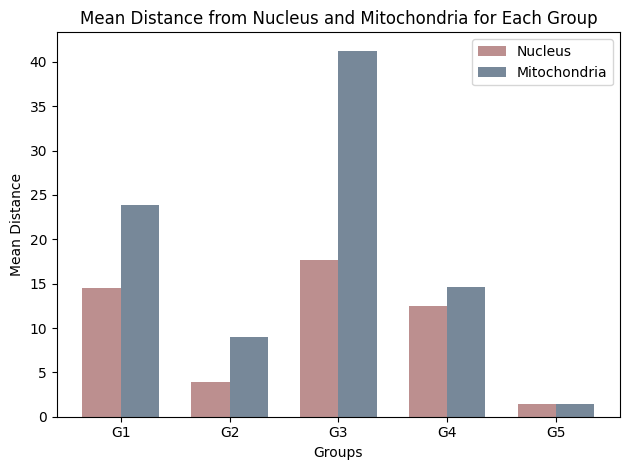

In [25]:
"""
    Plotting graphs to show difference in distance from nucleus and mitochondria for each group 
"""

x = summary_data['Group']
nucleus_means = summary_data['Mean_Distance_Nucleus']
mito_means = summary_data['Mean_Distance_Mitochondria']
x_indexes = range(len(x))
width = 0.35
plt.bar(x_indexes, nucleus_means, width=width, label='Nucleus', color='rosybrown')
plt.bar([i + width for i in x_indexes], mito_means, width=width, label='Mitochondria', color='lightslategrey')
plt.xlabel('Groups')
plt.ylabel('Mean Distance')
plt.title('Mean Distance from Nucleus and Mitochondria for Each Group')
plt.xticks([i + width / 2 for i in x_indexes], x)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/1490965914.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dist_nucl, labels=["group 1", "group2", "group 3", "group 4", "group 5"], showfliers=False)


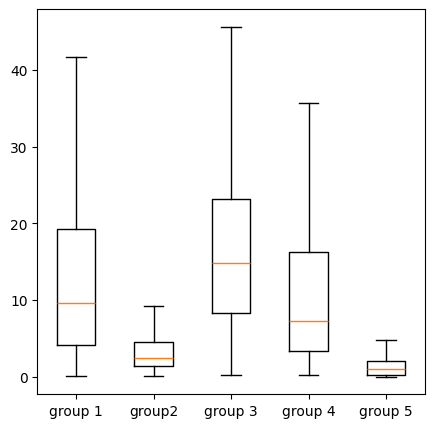

In [39]:
dist_nucl = [g1_master_table["mean_dist_nucleus"],  g2_master_table["mean_dist_nucleus"], g3_master_table["mean_dist_nucleus"],g4_master_table["mean_dist_nucleus"], g5_master_table["mean_dist_nucleus"]]

fig = plt.figure(figsize =(5,5))
plt.boxplot(dist_nucl, labels=["group 1", "group2", "group 3", "group 4", "group 5"], showfliers=False)

plt.show()

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/2162938.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dist_mito, labels=["group 1", "group2", "group 3", "group 4", "group 5"], showfliers=False)


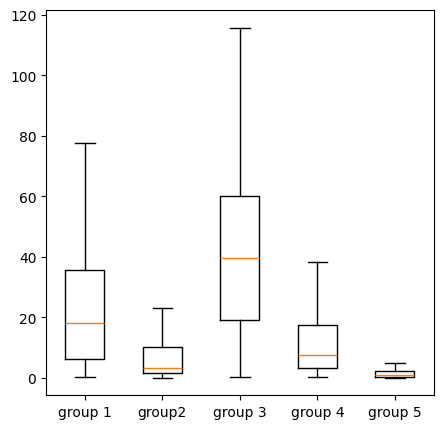

In [42]:
dist_mito = [g1_master_table["mean_dist_mito"],  g2_master_table["mean_dist_mito"], g3_master_table["mean_dist_mito"],g4_master_table["mean_dist_mito"], g5_master_table["mean_dist_nucleus"]]

fig = plt.figure(figsize =(5,5))
plt.boxplot(dist_mito, labels=["group 1", "group2", "group 3", "group 4", "group 5"], showfliers=False)

plt.show()

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/2244427956.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(n_pbody, labels=["group 1", "group2", "group 3", "group 4", "group 5"], showfliers=False)


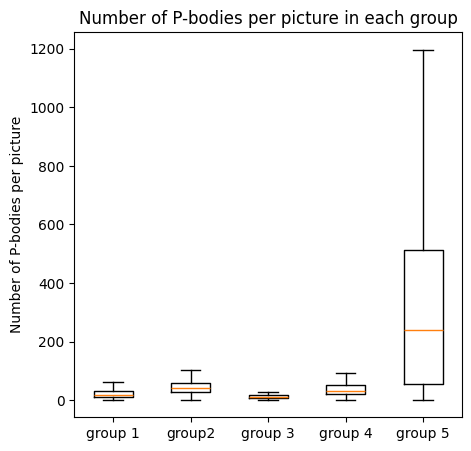

In [59]:
"""
    Create a boxplot that shows number of pbodies (n_pbody) per picture in each group
    for this, you calculate the total number of pbodies per group divided by the number of 
"""
n_pbody_g1 = g1_master_table['n_pbody']
n_pbody_g2 = g2_master_table['n_pbody']
n_pbody_g3 = g3_master_table['n_pbody']
n_pbody_g4 = g4_master_table['n_pbody']
n_pbody_g5 = g5_master_table['n_pbody']
n_pbody = [n_pbody_g1, n_pbody_g2, n_pbody_g3, n_pbody_g4, n_pbody_g5]
fig = plt.figure(figsize =(5,5))
plt.boxplot(n_pbody, labels=["group 1", "group2", "group 3", "group 4", "group 5"], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in each group')
plt.show()


## Boxplot G1 Medicines and Distance Nucleus & Mitochondria

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/3267554190.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g1_dist_nucleus, labels=g1_medicines)


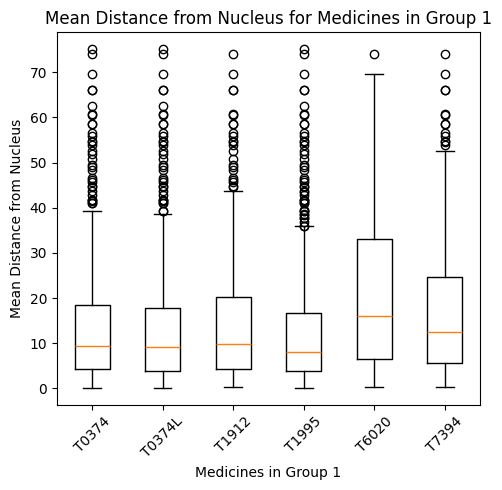

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/3267554190.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g1_dist_mito, labels=g1_medicines)


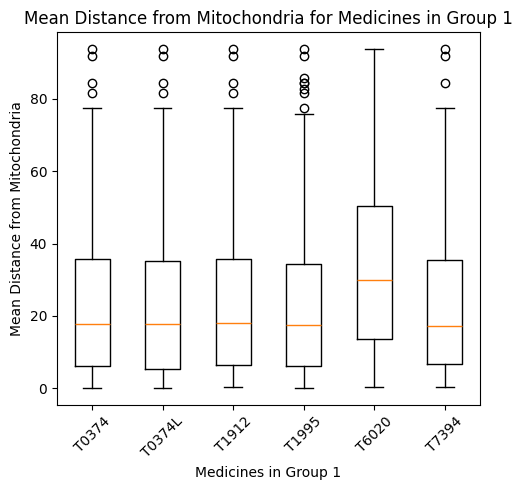

In [28]:
"""
     Create boxplot showing only medicines in G1 as x axis and distance from nucleus on y axis
"""
g1_medicines = g1_master_table['Medicine'].unique()
g1_dist_nucleus = [g1_master_table[g1_master_table['Medicine'] == med]['mean_dist_nucleus'] for med in g1_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g1_dist_nucleus, labels=g1_medicines)
plt.xlabel('Medicines in Group 1')
plt.ylabel('Mean Distance from Nucleus')
plt.title('Mean Distance from Nucleus for Medicines in Group 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"""
     Create boxplot showing only medicines in G1 as x axis and distance from mitochondria on y axis
"""
g1_dist_mito = [g1_master_table[g1_master_table['Medicine'] == med]['mean_dist_mito'] for med in g1_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g1_dist_mito, labels=g1_medicines)
plt.xlabel('Medicines in Group 1')
plt.ylabel('Mean Distance from Mitochondria')
plt.title('Mean Distance from Mitochondria for Medicines in Group 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




## Boxplot G2 Medicines and Distance Nucleus & Mitochondria

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/1134341860.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g2_dist_nucleus, labels=g2_medicines)


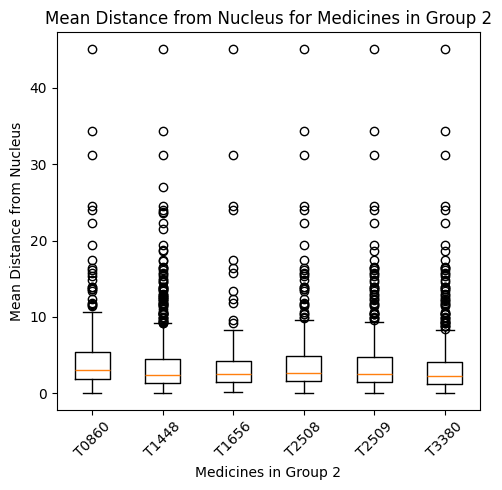

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/1134341860.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g2_dist_mito, labels=g2_medicines)


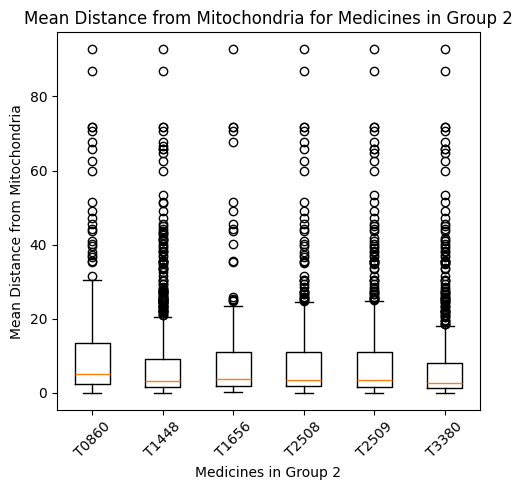

In [29]:
"""
     Create boxplot showing only medicines in G2 as x axis and distance from nucleus on y axis
"""
g2_medicines = g2_master_table['Medicine'].unique()
g2_dist_nucleus = [g2_master_table[g2_master_table['Medicine'] == med]['mean_dist_nucleus'] for med in g2_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g2_dist_nucleus, labels=g2_medicines)
plt.xlabel('Medicines in Group 2')
plt.ylabel('Mean Distance from Nucleus')
plt.title('Mean Distance from Nucleus for Medicines in Group 2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"""
     Create boxplot showing only medicines in G2 as x axis and distance from mitochondria on y axis
"""
g2_dist_mito = [g2_master_table[g2_master_table['Medicine'] == med]['mean_dist_mito'] for med in g2_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g2_dist_mito, labels=g2_medicines)
plt.xlabel('Medicines in Group 2')
plt.ylabel('Mean Distance from Mitochondria')
plt.title('Mean Distance from Mitochondria for Medicines in Group 2')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Boxplot G3 Medicines and Distance Nucleus & Mitochondria

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/367882031.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g3_dist_nucleus, labels=g3_medicines)


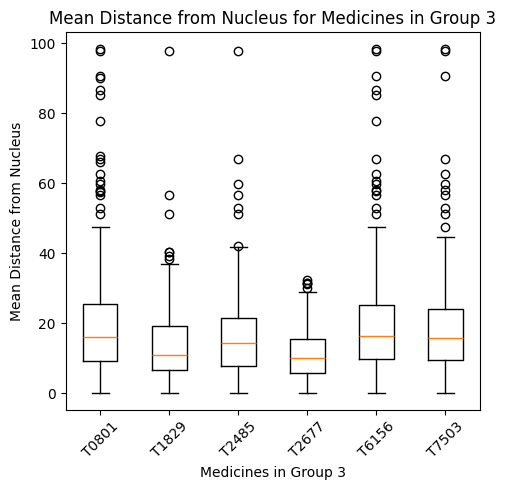

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/367882031.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g3_dist_mito, labels=g3_medicines)


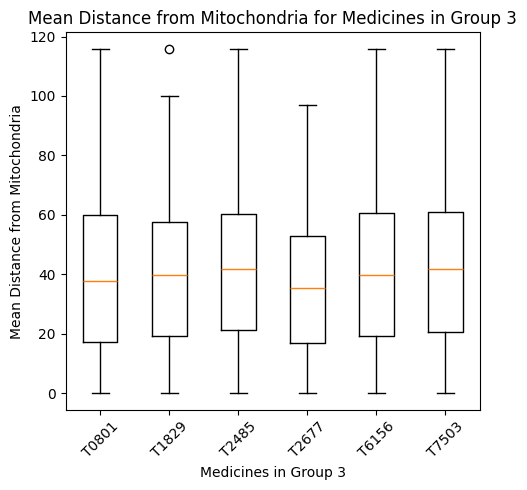

In [30]:
"""
     Create boxplot showing only medicines in G3 as x axis and distance from nucleus on y axis
"""
g3_medicines = g3_master_table['Medicine'].unique()
g3_dist_nucleus = [g3_master_table[g3_master_table['Medicine'] == med]['mean_dist_nucleus'] for med in g3_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g3_dist_nucleus, labels=g3_medicines)
plt.xlabel('Medicines in Group 3')
plt.ylabel('Mean Distance from Nucleus')
plt.title('Mean Distance from Nucleus for Medicines in Group 3')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"""
     Create boxplot showing only medicines in G3 as x axis and distance from mitochondria on y axis
"""
g3_dist_mito = [g3_master_table[g3_master_table['Medicine'] == med]['mean_dist_mito'] for med in g3_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g3_dist_mito, labels=g3_medicines)
plt.xlabel('Medicines in Group 3')
plt.ylabel('Mean Distance from Mitochondria')
plt.title('Mean Distance from Mitochondria for Medicines in Group 3')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Boxplot G4 Medicines and Distance Nucleus & Mitochondria

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/2391585504.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g4_dist_nucleus, labels=g4_medicines)


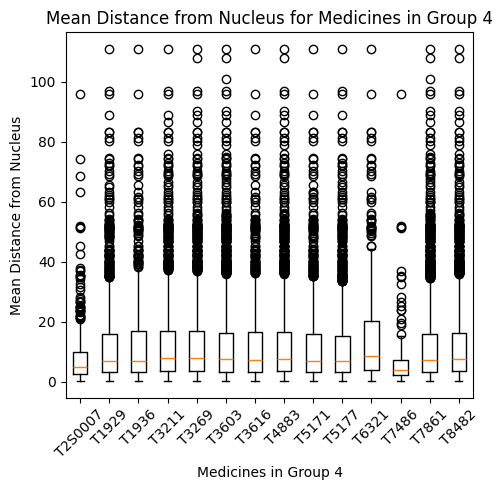

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/2391585504.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g4_dist_mito, labels=g4_medicines)


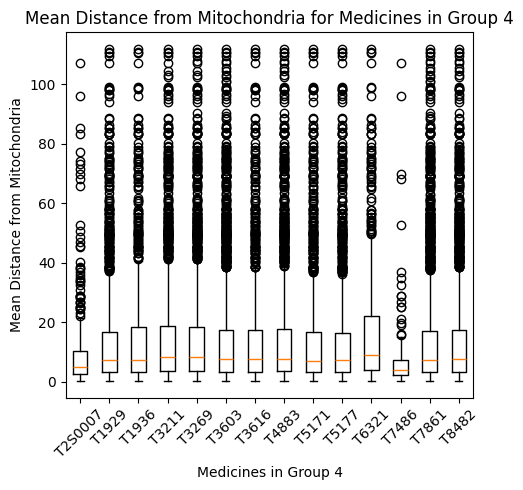

In [31]:
"""
     Create boxplot showing only medicines in G4 as x axis and distance from nucleus on y axis
"""
g4_medicines = g4_master_table['Medicine'].unique()
g4_dist_nucleus = [g4_master_table[g4_master_table['Medicine'] == med]['mean_dist_nucleus'] for med in g4_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g4_dist_nucleus, labels=g4_medicines)
plt.xlabel('Medicines in Group 4')
plt.ylabel('Mean Distance from Nucleus')
plt.title('Mean Distance from Nucleus for Medicines in Group 4')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"""
     Create boxplot showing only medicines in G4 as x axis and distance from mitochondria on y axis
"""
g4_dist_mito = [g4_master_table[g4_master_table['Medicine'] == med]['mean_dist_mito'] for med in g4_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g4_dist_mito, labels=g4_medicines)
plt.xlabel('Medicines in Group 4')
plt.ylabel('Mean Distance from Mitochondria')
plt.title('Mean Distance from Mitochondria for Medicines in Group 4')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Boxplot G5 Medicines and Distance Nucleus & Mitochondria

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/2426813898.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g5_dist_nucleus, labels=g5_medicines)


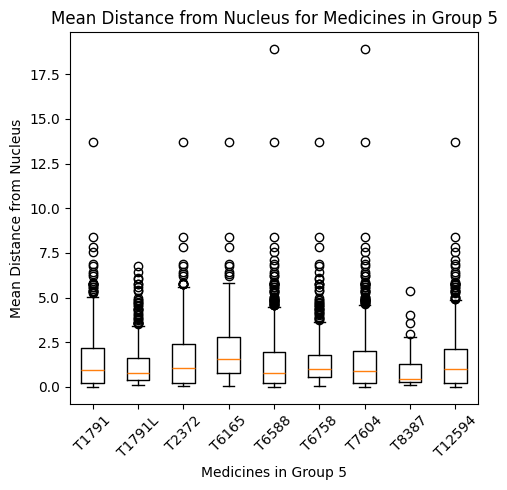

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_89217/2426813898.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(g5_dist_mito, labels=g5_medicines)


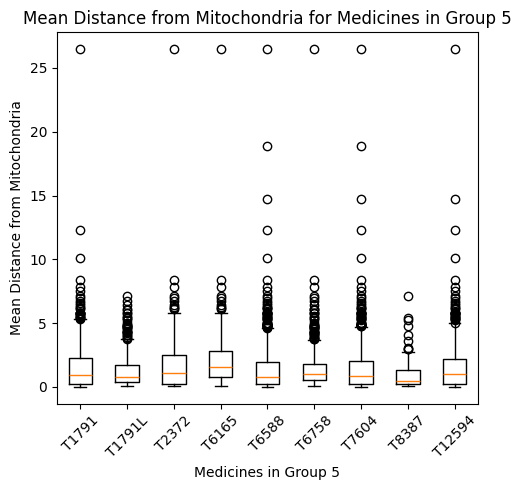

In [32]:
"""
     Create boxplot showing only medicines in G5 as x axis and distance from nucleus on y axis
"""
g5_medicines = g5_master_table['Medicine'].unique()
g5_dist_nucleus = [g5_master_table[g5_master_table['Medicine'] == med]['mean_dist_nucleus'] for med in g5_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g5_dist_nucleus, labels=g5_medicines)
plt.xlabel('Medicines in Group 5')
plt.ylabel('Mean Distance from Nucleus')
plt.title('Mean Distance from Nucleus for Medicines in Group 5')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"""
     Create boxplot showing only medicines in G5 as x axis and distance from mitochondria on y axis
"""
g5_dist_mito = [g5_master_table[g5_master_table['Medicine'] == med]['mean_dist_mito'] for med in g5_medicines]
fig = plt.figure(figsize=(5, 5))
plt.boxplot(g5_dist_mito, labels=g5_medicines)
plt.xlabel('Medicines in Group 5')
plt.ylabel('Mean Distance from Mitochondria')
plt.title('Mean Distance from Mitochondria for Medicines in Group 5')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()